# Эксперимент: FluentNet (waveform + mel) + SpecAugment

**Модель:** Двухветочная архитектура — 1D CNN (waveform) + 2D CNN (mel) → конкатенация → FC  
**Группа:** 02_spectrogram_models  
**Ориентир:** checkpoint_3/exp_12 — F1-bad=0.610, ROC-AUC=0.785

## Исправления по сравнению с checkpoint_3/exp_12

1. **Holdout test изолирован** до обучения.
2. **Оптимизация порога** по F1-bad на val.
3. **Early stopping** с сохранением лучшего чекпоинта.
4. **SpecAugment** при обучении.

In [1]:
import sys
from pathlib import Path
import numpy as np
import time
from joblib import Parallel, delayed
import mlflow
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score as _f1
import matplotlib.pyplot as plt

exp_dir = Path().resolve()
sys.path.insert(0, str(exp_dir.parent.parent))
sys.path.insert(0, str(exp_dir))

from shared import config, data_utils, train_utils
from shared.evaluate import find_optimal_threshold, evaluate
from shared.results_utils import save_result_csv
from shared.mlflow_utils import start_run, log_epoch, log_artifact_if_exists
from model import get_model

train_utils.set_seed(config.RANDOM_STATE)

/Users/dk/miniconda3/envs/vkr/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
(
    paths_trainval, labels_trainval, letters_trainval,
    paths_test, labels_test, letters_test,
) = data_utils.get_holdout_split()

idx = np.arange(len(paths_trainval))
idx_tr, idx_val = train_test_split(
    idx, test_size=0.18, stratify=labels_trainval, random_state=config.RANDOM_STATE
)
paths_train,   paths_val   = paths_trainval[idx_tr],   paths_trainval[idx_val]
labels_train,  labels_val  = labels_trainval[idx_tr],  labels_trainval[idx_val]
letters_train, letters_val = letters_trainval[idx_tr], letters_trainval[idx_val]
print(f"Train: {len(paths_train)}, Val: {len(paths_val)}, Test: {len(paths_test)}")

Train: 1934, Val: 425, Test: 417


In [3]:
SR       = config.TARGET_SR
MAX_LEN  = int(SR * config.MAX_DURATION_SEC)
N_MELS   = config.N_MELS
N_FRAMES = 320

def load_waveform(path):
    y, _ = data_utils.load_audio(path, sr=SR)
    if len(y) < MAX_LEN:
        y = np.pad(y, (0, MAX_LEN - len(y)))
    return y[:MAX_LEN].astype(np.float32)

print("Waveform train...")
W_train = np.stack(Parallel(n_jobs=-1)(delayed(load_waveform)(p) for p in paths_train))
W_val   = np.stack(Parallel(n_jobs=-1)(delayed(load_waveform)(p) for p in paths_val))
W_test  = np.stack(Parallel(n_jobs=-1)(delayed(load_waveform)(p) for p in paths_test))

def load_mel(path):
    return data_utils.extract_mel_spectrogram(path, max_frames=N_FRAMES)[np.newaxis, ...]

print("Mel train...")
M_train = np.stack(Parallel(n_jobs=-1)(delayed(load_mel)(p) for p in paths_train))
M_val   = np.stack(Parallel(n_jobs=-1)(delayed(load_mel)(p) for p in paths_val))
M_test  = np.stack(Parallel(n_jobs=-1)(delayed(load_mel)(p) for p in paths_test))

mel_mean = M_train.mean(axis=(0, 2, 3), keepdims=True)
mel_std  = np.where(M_train.std(axis=(0, 2, 3), keepdims=True) < 1e-6, 1.0,
                    M_train.std(axis=(0, 2, 3), keepdims=True))
M_train = (M_train - mel_mean) / mel_std
M_val   = (M_val   - mel_mean) / mel_std
M_test  = (M_test  - mel_mean) / mel_std
print(f"Waveform: {W_train.shape}  Mel: {M_train.shape}")

Waveform train...
Mel train...
Waveform: (1934, 160000)  Mel: (1934, 1, 80, 320)


In [4]:
class FluentNetDataset(Dataset):
    def __init__(self, W, M, letters, labels, augment=False):
        self.W, self.M = W, M
        self.letters, self.labels, self.augment = letters, labels, augment
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        m = self.M[i].copy()
        if self.augment:
            m = data_utils.augment_mel_spectrogram(m)
        return (
            torch.from_numpy(self.W[i]).float(),
            torch.from_numpy(m).float(),
            torch.from_numpy(self.letters[i]).float(),
            int(self.labels[i]),
        )

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
BATCH = 16
train_loader = DataLoader(FluentNetDataset(W_train, M_train, letters_train, labels_train, augment=True),  batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(FluentNetDataset(W_val,   M_val,   letters_val,   labels_val,   augment=False), batch_size=BATCH, shuffle=False)
test_loader  = DataLoader(FluentNetDataset(W_test,  M_test,  letters_test,  labels_test,  augment=False), batch_size=BATCH, shuffle=False)

/Users/dk/miniconda3/envs/vkr/lib/python3.10/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


Epoch 1/60  loss=0.6687  val_f1=0.5928
Epoch 2/60  loss=0.6550  val_f1=0.4764
Epoch 3/60  loss=0.6486  val_f1=0.5644
Epoch 4/60  loss=0.6442  val_f1=0.6894
Epoch 5/60  loss=0.6191  val_f1=0.6584
Epoch 6/60  loss=0.6280  val_f1=0.6831
Epoch 7/60  loss=0.6157  val_f1=0.4474
Epoch 8/60  loss=0.6109  val_f1=0.6229
Epoch 9/60  loss=0.6164  val_f1=0.6983
Epoch 10/60  loss=0.6077  val_f1=0.6954
Epoch 11/60  loss=0.6075  val_f1=0.6685
Epoch 12/60  loss=0.6083  val_f1=0.7167
Epoch 13/60  loss=0.6041  val_f1=0.6912
Epoch 14/60  loss=0.6029  val_f1=0.6260
Epoch 15/60  loss=0.6029  val_f1=0.6708
Epoch 16/60  loss=0.6030  val_f1=0.6463
Epoch 17/60  loss=0.6042  val_f1=0.4688
Epoch 18/60  loss=0.5967  val_f1=0.6637
Epoch 19/60  loss=0.5874  val_f1=0.6360
Epoch 20/60  loss=0.5792  val_f1=0.7115
Epoch 21/60  loss=0.5765  val_f1=0.6972
Epoch 22/60  loss=0.5653  val_f1=0.7104
Early stopping на эпохе 22
              precision    recall  f1-score   support

        good       0.82      0.88      0.85    

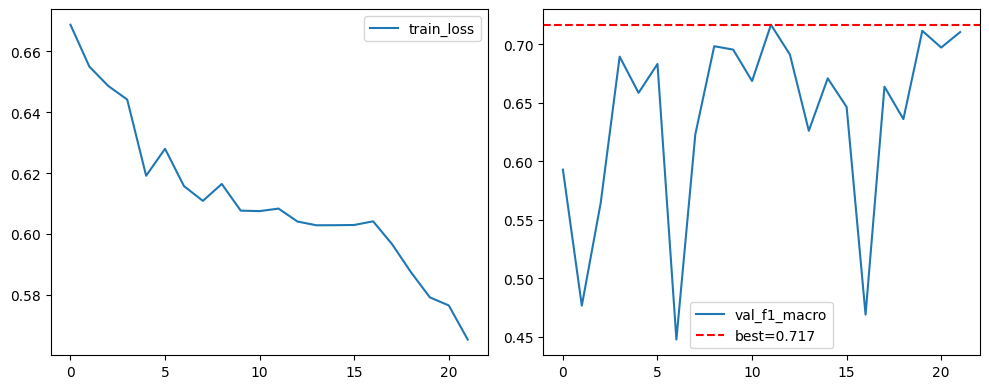

Результаты сохранены


In [5]:
N_EPOCHS   = 60
BRANCH_DIM = 128
DROPOUT    = 0.3
n_letters  = letters_train.shape[1]

with start_run("exp_fluentnet", group="02_spectrogram_models"):

    mlflow.log_params({
        "model":        "FluentNet (1D CNN + 2D CNN)",
        "n_mels":       N_MELS,
        "n_frames":     N_FRAMES,
        "branch_dim":   BRANCH_DIM,
        "dropout":      DROPOUT,
        "augment":      "SpecAugment",
        "n_epochs":     N_EPOCHS,
        "optimizer":    "AdamW",
        "lr":           1e-3,
        "early_stopping_patience": config.EARLY_STOPPING_PATIENCE,
    })

    model = get_model(
        waveform_len=MAX_LEN, n_mels=N_MELS, n_frames=N_FRAMES,
        num_classes=2, n_letters=n_letters, branch_dim=BRANCH_DIM, dropout=DROPOUT
    ).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    mlflow.log_param("num_params", n_params)

    weights = compute_class_weight("balanced", classes=np.unique(labels_train), y=labels_train)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32, device=device))
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = train_utils.get_lr_scheduler(optimizer)
    early_stopping = train_utils.EarlyStopping(patience=config.EARLY_STOPPING_PATIENCE)
    best_ckpt, best_f1 = exp_dir / "best_ckpt.pt", -1.0

    def eval_loader(loader):
        model.eval()
        logits_list, true_list = [], []
        with torch.no_grad():
            for wav, mel, letters, y in loader:
                logits_list.append(model(wav.to(device), mel.to(device), letters.to(device)).cpu().numpy())
                true_list.extend(y.tolist())
        logits = np.concatenate(logits_list)
        proba  = torch.softmax(torch.from_numpy(logits), dim=1).numpy()[:, config.CLASS_BAD]
        return proba, np.array(true_list)

    train_losses, val_f1s = [], []
    t0 = time.perf_counter()

    for epoch in range(N_EPOCHS):
        model.train()
        losses = []
        for wav, mel, letters, y in train_loader:
            wav, mel, letters, y = wav.to(device), mel.to(device), letters.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(wav, mel, letters), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), config.DEFAULT_GRAD_CLIP)
            optimizer.step()
            losses.append(loss.item())
        train_loss = np.mean(losses)
        train_losses.append(train_loss)

        val_proba, val_true = eval_loader(val_loader)
        val_f1 = _f1(val_true, (val_proba >= 0.5).astype(int), average="macro")
        val_f1s.append(val_f1)

        log_epoch(epoch, train_loss=train_loss, val_f1_macro=val_f1,
                  lr=optimizer.param_groups[0]["lr"])

        if val_f1 > best_f1:
            best_f1 = val_f1
            train_utils.save_best_checkpoint(model, best_ckpt)
        scheduler.step(val_f1)
        print(f"Epoch {epoch+1}/{N_EPOCHS}  loss={train_loss:.4f}  val_f1={val_f1:.4f}")
        if early_stopping.step(val_f1):
            print(f"Early stopping на эпохе {epoch+1}")
            break

    train_time_sec = time.perf_counter() - t0
    train_utils.load_best_checkpoint(model, best_ckpt, device)

    val_proba, val_true = eval_loader(val_loader)
    optimal_threshold = find_optimal_threshold(val_true, val_proba)
    test_proba, test_true = eval_loader(test_loader)
    test_metrics = evaluate(test_true, test_proba, threshold=optimal_threshold, verbose=True)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(train_losses, label="train_loss"); axes[0].legend()
    axes[1].plot(val_f1s, label="val_f1_macro")
    axes[1].axhline(best_f1, color="r", linestyle="--", label=f"best={best_f1:.3f}"); axes[1].legend()
    plt.tight_layout()
    fig.savefig(exp_dir / "training_curves.png", dpi=120)
    plt.show()

    save_result_csv(
        exp_dir=exp_dir, experiment_id="exp_fluentnet",
        experiment_name="FluentNet (waveform + mel) + SpecAugment",
        model="FluentNetClassifier",
        accuracy=test_metrics["accuracy"], f1_macro=test_metrics["f1_macro"],
        f1_bad=test_metrics["f1_bad"],     roc_auc=test_metrics["roc_auc"],
        precision_bad=test_metrics["precision_bad"], recall_bad=test_metrics["recall_bad"],
        threshold=test_metrics["threshold"],
        notes=f"SpecAugment + holdout | thr={optimal_threshold:.2f} | branch_dim={BRANCH_DIM}",
        num_params=n_params, train_time_sec=train_time_sec,
    )
    log_artifact_if_exists(exp_dir / "training_curves.png")
    print("Результаты сохранены")